In [1]:
import dgl
import torch
import CAST
import os
import numpy as np
import anndata as ad
import scanpy as sc
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from CAST import CAST_MARK
from CAST.visualize import kmeans_plot_multiple
from CAST import CAST_STACK
from CAST.CAST_Stack import reg_params
from CAST.models.model_GCNII import Args
from scipy.sparse import issparse
from scipy.spatial import cKDTree
from sklearn.neighbors import NearestNeighbors



In [6]:
adataMeta1_roi = sc.read_h5ad("/p2/zulab/jtian/data/SA/embyro/output_em5/adataMeta1_roi.h5ad")
adataMeta2_roi = sc.read_h5ad("/p2/zulab/jtian/data/SA/embyro/output_em5/adataMeta2_roi.h5ad")
adataTrans1_roi = sc.read_h5ad("/p2/zulab/jtian/data/SA/embyro/output_em5/adataTrans1_roi.h5ad")
adataTrans2_roi = sc.read_h5ad("/p2/zulab/jtian/data/SA/embyro/output_em5/adataTrans2_roi.h5ad")

In [2]:
GPU_ID = 0 if torch.cuda.is_available() else -1

In [3]:
def get_xy(adata):
    if ("x" in adata.obs.columns) and ("y" in adata.obs.columns):
        return np.asarray(adata.obs[["x", "y"]], dtype=np.float32)
    if "spatial" in adata.obsm:
        return np.asarray(adata.obsm["spatial"], dtype=np.float32)
    raise ValueError("找不到坐标：需要 adata.obs['x','y'] 或 adata.obsm['spatial']")

def norm_xy_to(XY, target=2000):
    XY = XY.astype(np.float32)
    XY = XY - XY.min(axis=0)
    mx = XY.max(axis=0)
    s = target / (mx.max() + 1e-8)
    return XY * s

def to_float32_array(X):
    try:
        import scipy.sparse as sp
        if sp.issparse(X):
            return X.toarray().astype(np.float32)
    except Exception:
        pass
    return np.asarray(X, dtype=np.float32)

def get_hvg_mask(adata, fallback_top=2000):
    """
    优先使用 adata.var['highly_variable']。
    如果不存在或数量不够/为0，则退化为取前 fallback_top 个基因（按当前 var 顺序）。
    """
    if "highly_variable" in adata.var.columns:
        hv = adata.var["highly_variable"].to_numpy()
        if hv.dtype != bool:
            hv = hv.astype(bool)
        cnt = int(hv.sum())
        if cnt > 0:
            return hv
    # fallback：直接取前 fallback_top
    hv = np.zeros(adata.n_vars, dtype=bool)
    hv[:min(fallback_top, adata.n_vars)] = True
    return hv

In [20]:
output_path='/p2/zulab/jtian/data/SA/embyro/output_em5'

In [ ]:
#trans1 meta1

In [7]:

# --- 取 trans HVG (约2000) ---
hvg = get_hvg_mask(adataTrans1_roi, fallback_top=2000)
X_trans = to_float32_array(adataTrans1_roi[:, hvg].X)   # (n_trans_roi, ~2000)
X_meta  = to_float32_array(adataMeta1_roi.X) 

In [10]:
exp_dict = {
    "trans1": X_trans.astype(np.float32),
    "meta1":  X_meta.astype(np.float32),
}

In [11]:
adataMeta1_roi

AnnData object with n_obs × n_vars = 1636 × 194
    obs: 'x', 'y', 'sample', 'in_circle_700_1000_r100'
    var: 'mean', 'std'
    uns: 'log1p', 'xy_circle_700_1000_r100_sel'
    obsm: 'xy_circle_700_1000_r100'
    layers: 'raw'

In [15]:
adataMeta1_roi.obs['y']

SpotIndex
59981    5034
59982    5034
59983    5034
59984    5034
59985    5034
         ... 
75048    4134
75049    4134
75050    4134
75051    4134
75052    4134
Name: y, Length: 1636, dtype: int64

In [18]:
coords_raw = {
    "trans1": np.array(adataTrans1_roi.obs[['x','y']]),
    "meta1":  np.array(adataMeta1_roi.obs[['x','y']])
}

In [19]:
args = Args(
    dataname='e1',
    gpu=GPU_ID,
    epochs=1000,
    lr1=1e-3,
    wd1=0,
    lambd=1e-3,
    n_layers=9,
    der=0.5,
    dfr=0.3,
    use_encoder=True,
    encoder_dim=100,
)

Constructing delaunay graphs for 2 samples...


/p1/zulab_users/jtian/my_jupyter/SA/CAST-main/CAST/utils.py:16: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  delaunay_graph = weights.Rook.from_dataframe(cells).to_networkx()
/p1/zulab_users/jtian/anaconda3/envs/my_NewSA_py39/lib/python3.9/site-packages/torch/cuda/__init__.py:145: UserWarning: 
NVIDIA H100 PCIe with CUDA capability sm_90 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_37 sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 compute_37.
If you want to use the NVIDIA H100 PCIe GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(incompatible_device_warn.format(device_name, capability, " ".join(arch_list), device_name))
/p1/zulab_users/jtian/my_jupyter/SA/CAST-main/CAST/utils.py:16: FutureWarning: `use_index` defaults to False but will default to True i

[CAST_MARK] in_dim_map: {'trans1': 2000, 'meta1': 194}
Training on cuda:0...


Loss: -66.673 step time=0.069s: 100%|██████████| 1000/1000 [10:10<00:00,  1.64it/s]  


Finished.
The embedding, log, model files were saved to /p2/zulab/jtian/data/SA/embyro/output_em5


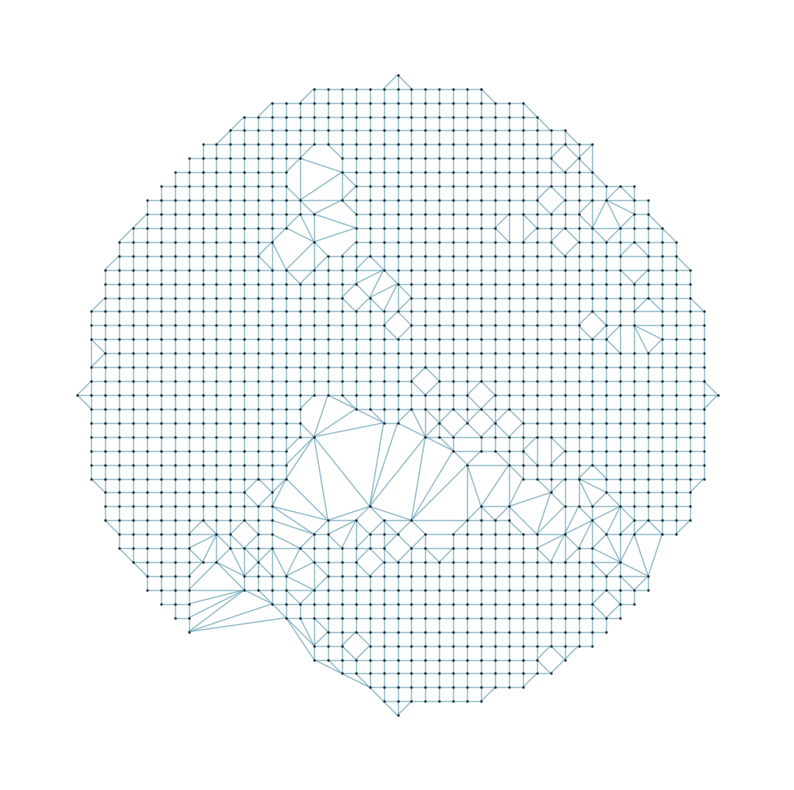

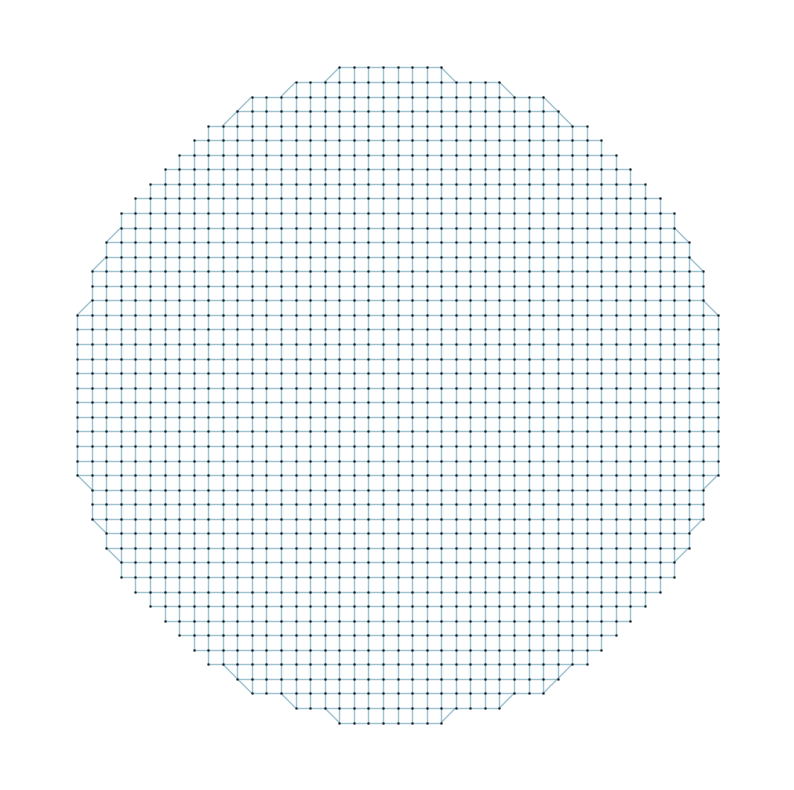

In [21]:
embed_dict = CAST_MARK(coords_raw,exp_dict,output_path,args=args)

In [22]:
samples=['trans1','meta1']

Perform KMeans clustering on 3006 cells...
Plotting the KMeans clustering results...


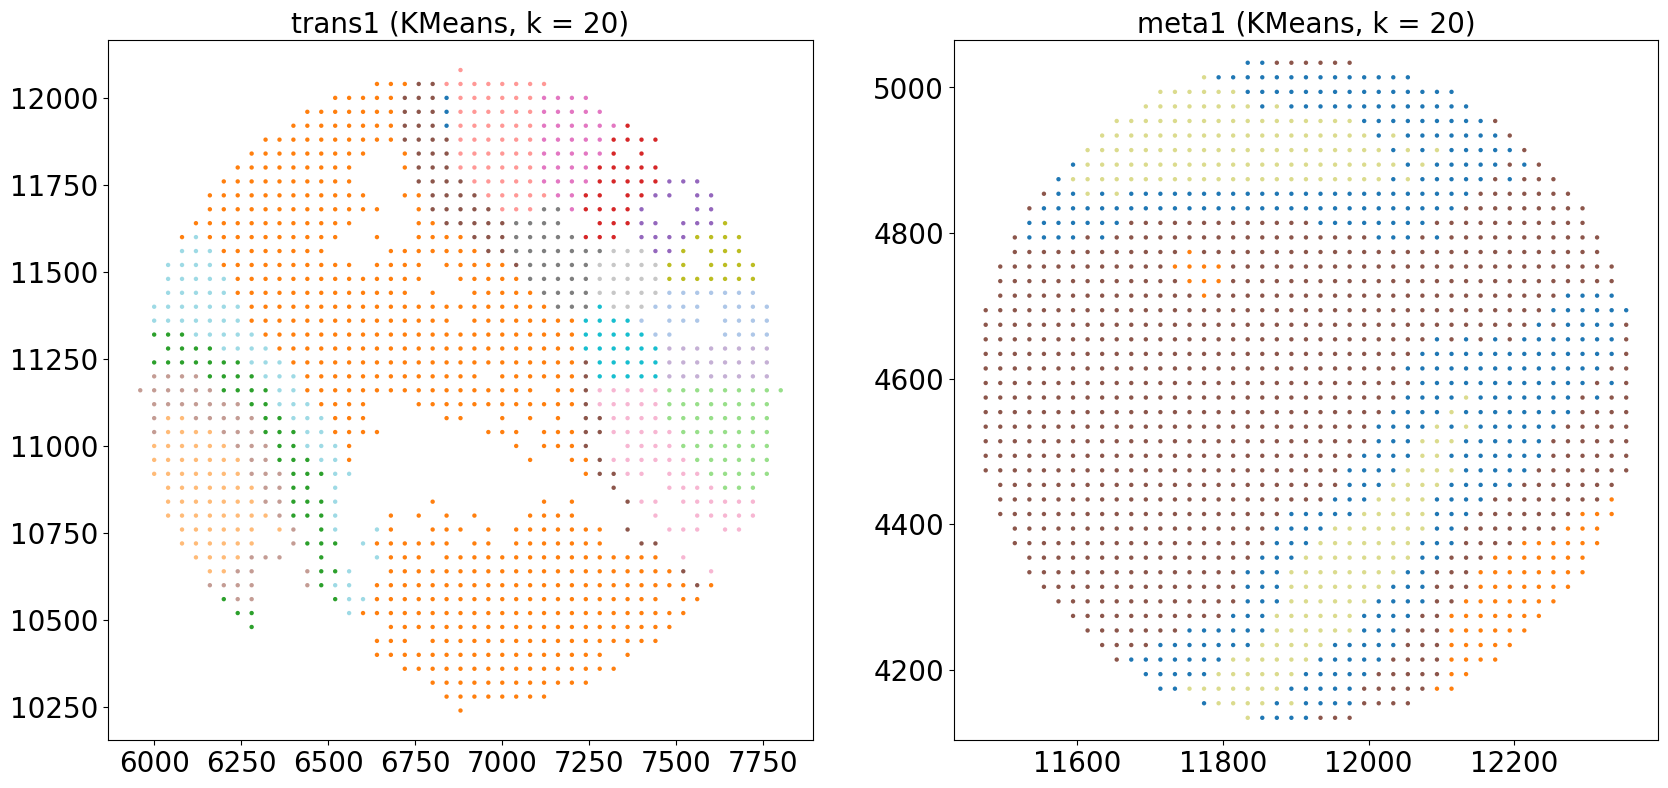

In [ ]:
cell_label = kmeans_plot_multiple(embed_dict,samples,coords_raw,'demo1',output_path,k=20,dot_size = 10,minibatch=False)
torch.save(cell_label, os.path.join(output_path, f"{samples[0]}_{samples[1]}_cell_label_dict_k20.pt"))

loss_log type: <class 'list'>
loss_log keys/info: [3.0104293823242188, 1.819242000579834, 1.6120524406433105, 1.93589186668396, -1.8794190883636475, 2.1763434410095215, -1.8611421585083008, 0.4570441246032715, -2.723381519317627, -1.128216028213501, -0.6894259452819824, -5.861970901489258, -5.854526519775391, -3.7558038234710693, -9.280765533447266, -5.929829120635986, -11.665983200073242, -10.949600219726562, -11.244647026062012, -10.095187187194824, -14.016836166381836, -16.14995765686035, -17.97623634338379, -17.157163619995117, -14.655303001403809, -13.224279403686523, -18.05426788330078, -20.222639083862305, -21.180662155151367, -18.972902297973633, -24.827730178833008, -22.039264678955078, -28.59364128112793, -14.48299503326416, -26.773603439331055, -19.006877899169922, -21.33677864074707, -23.508989334106445, -18.041650772094727, -27.606739044189453, -34.72220230102539, -31.3641357421875, -33.70661163330078, -26.870525360107422, -33.205421447753906, -27.790979385375977, -31.1112

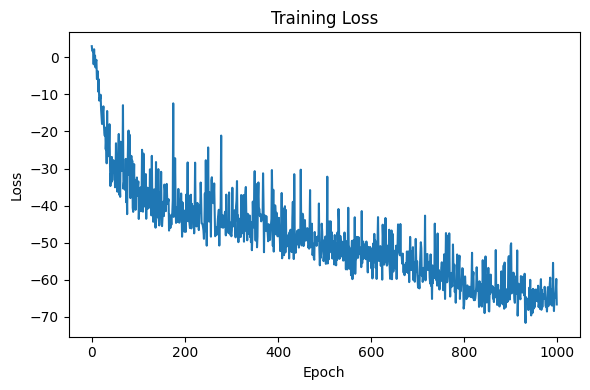

In [31]:

loss_log = torch.load("/p2/zulab/jtian/data/SA/embyro/output_em5/demo_loss_log.pt", map_location="cpu")
print("loss_log type:", type(loss_log))
print("loss_log keys/info:", loss_log if not hasattr(loss_log, "keys") else list(loss_log.keys()))
import matplotlib.pyplot as plt
if isinstance(loss_log, (list, tuple)):
    plt.figure(figsize=(6,4))
    plt.plot(loss_log)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.tight_layout()
    plt.show()

In [ ]:
# embed_dict = torch.load(f'{output_path}/demo_embed_dict.pt',map_location='cpu')


Loss: 1296.872: 100%|██████████| 1/1 [00:00<00:00, 64.58it/s]
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not fo

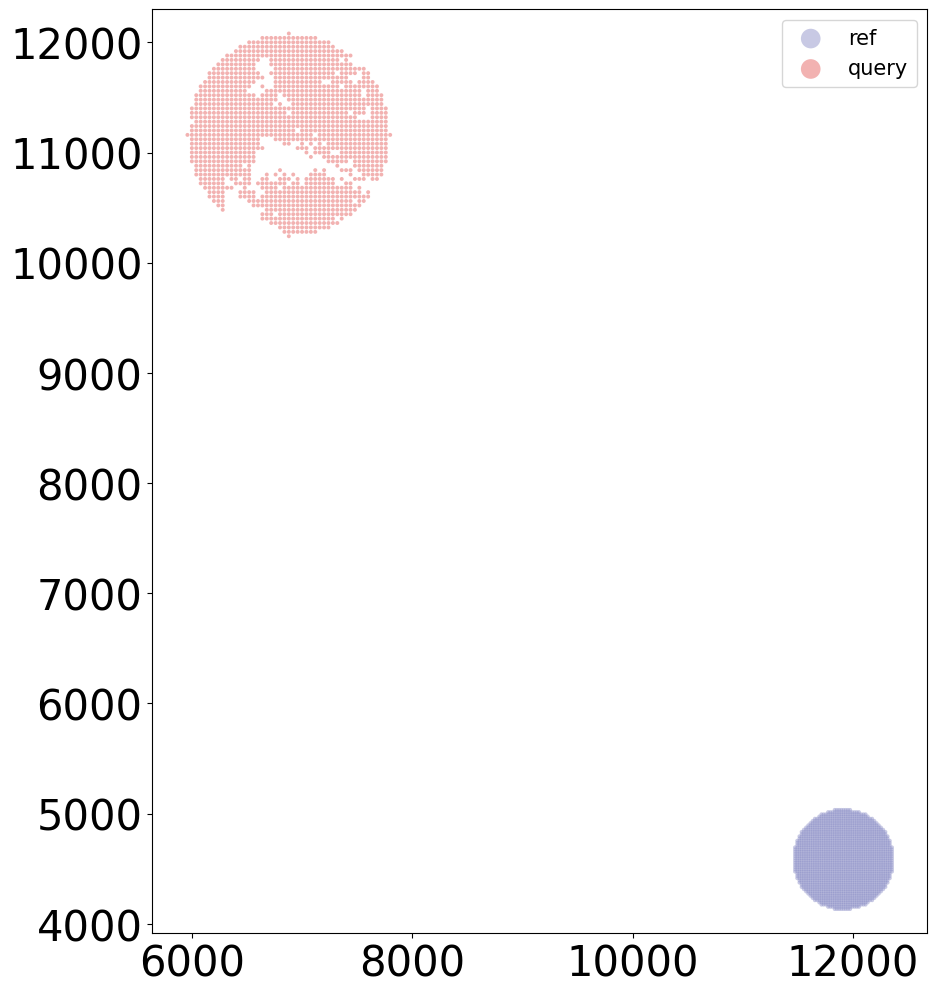

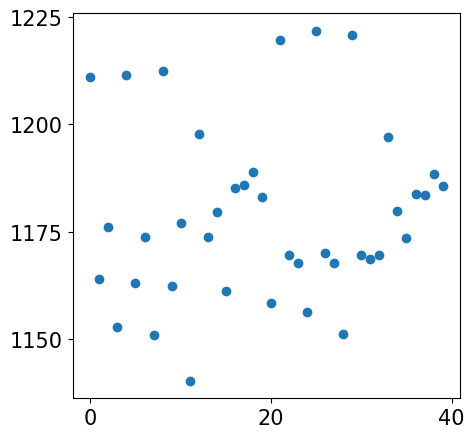

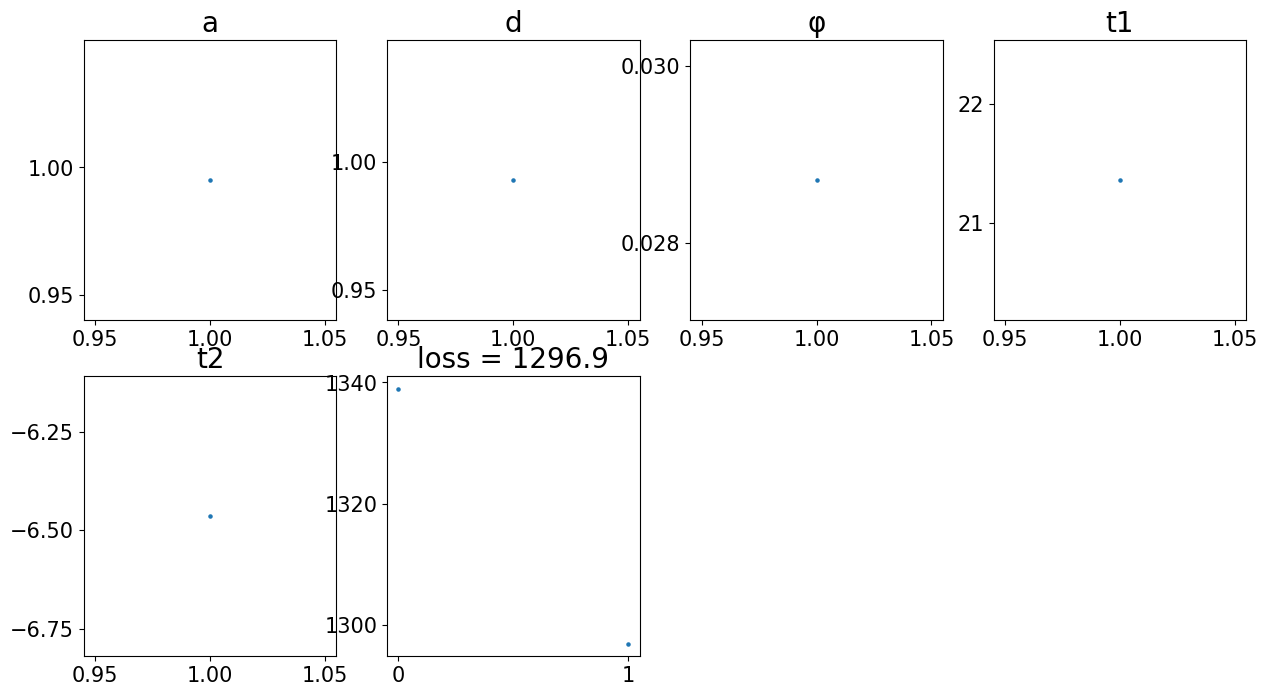

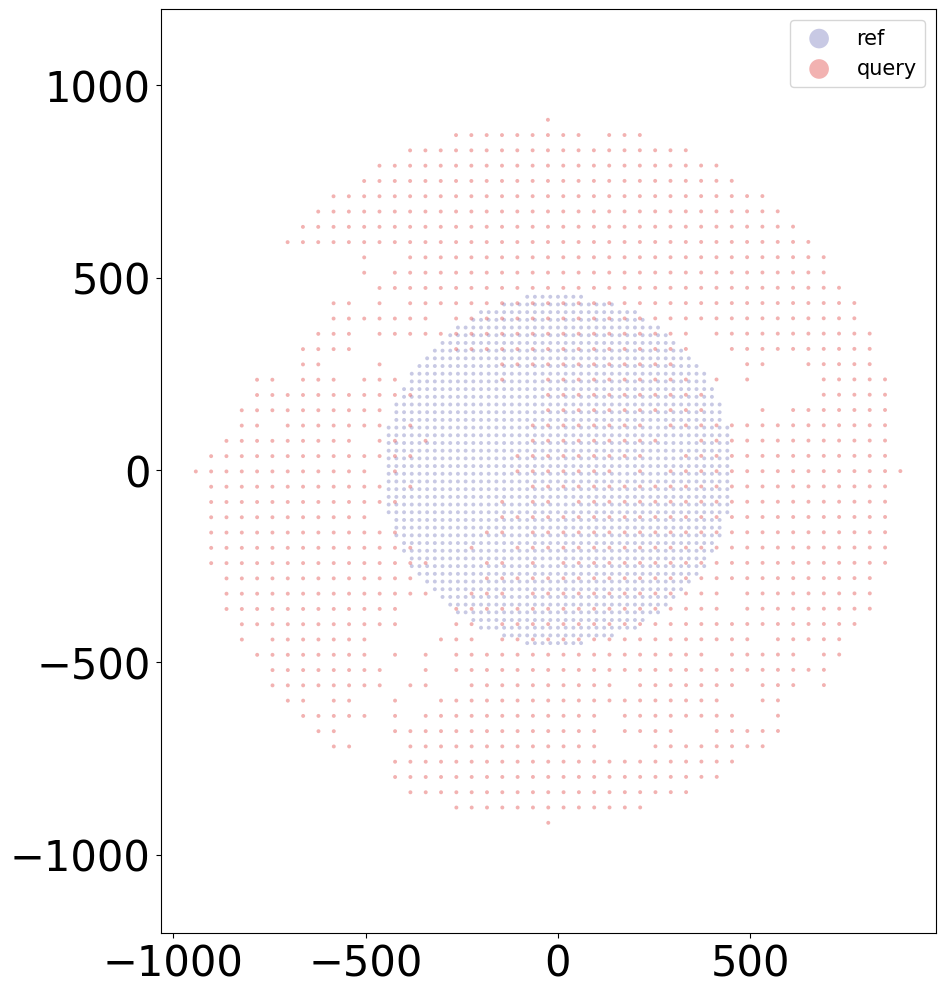

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


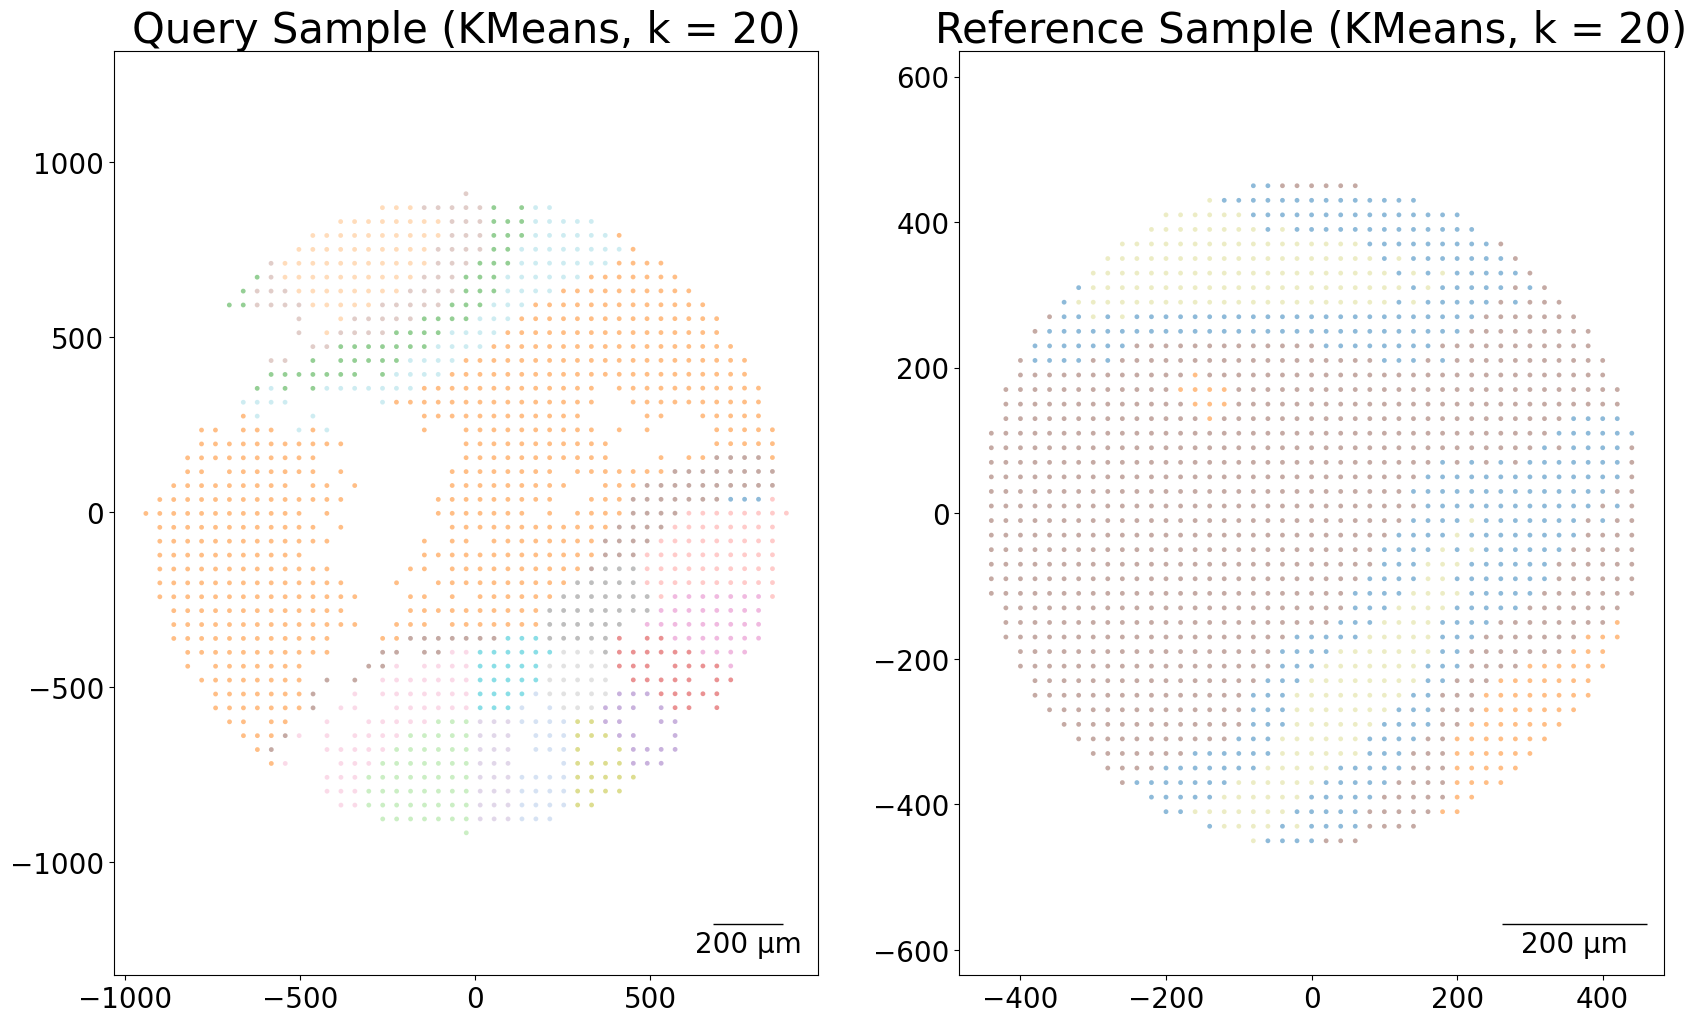

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


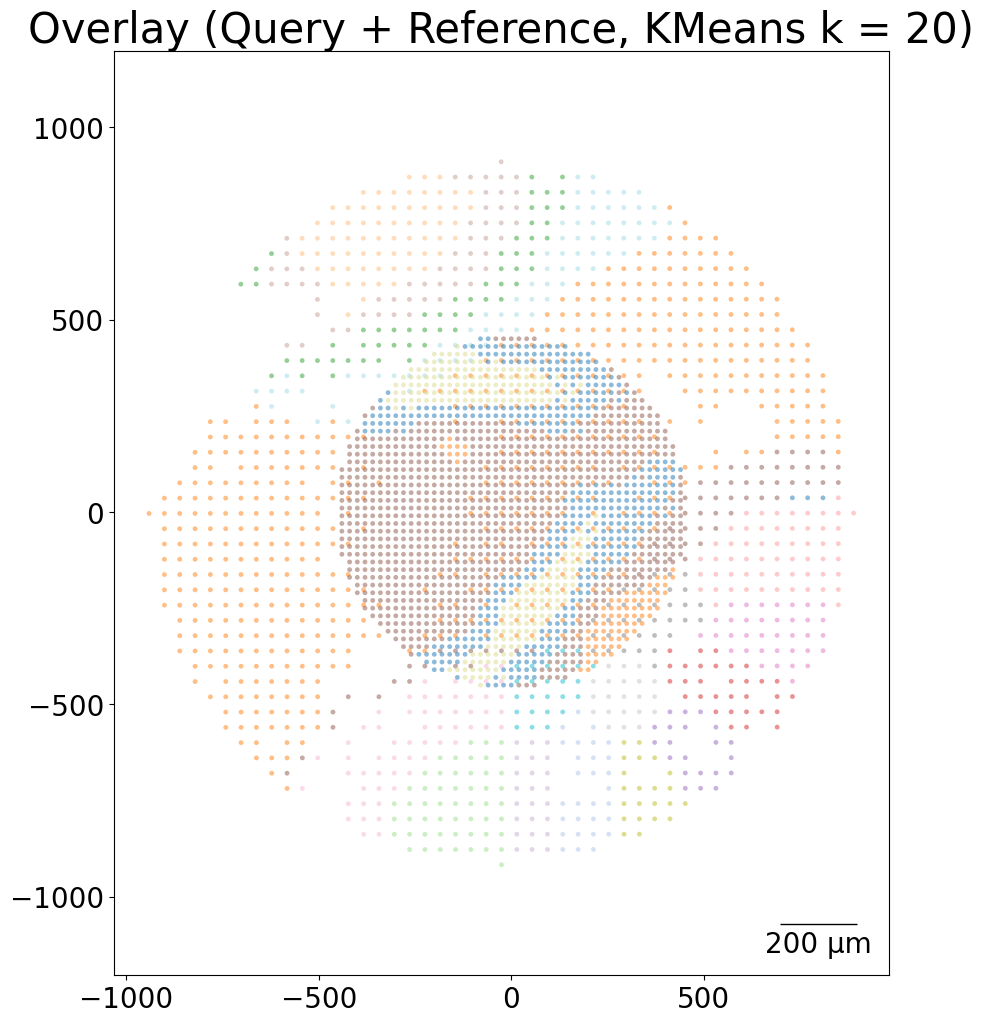

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


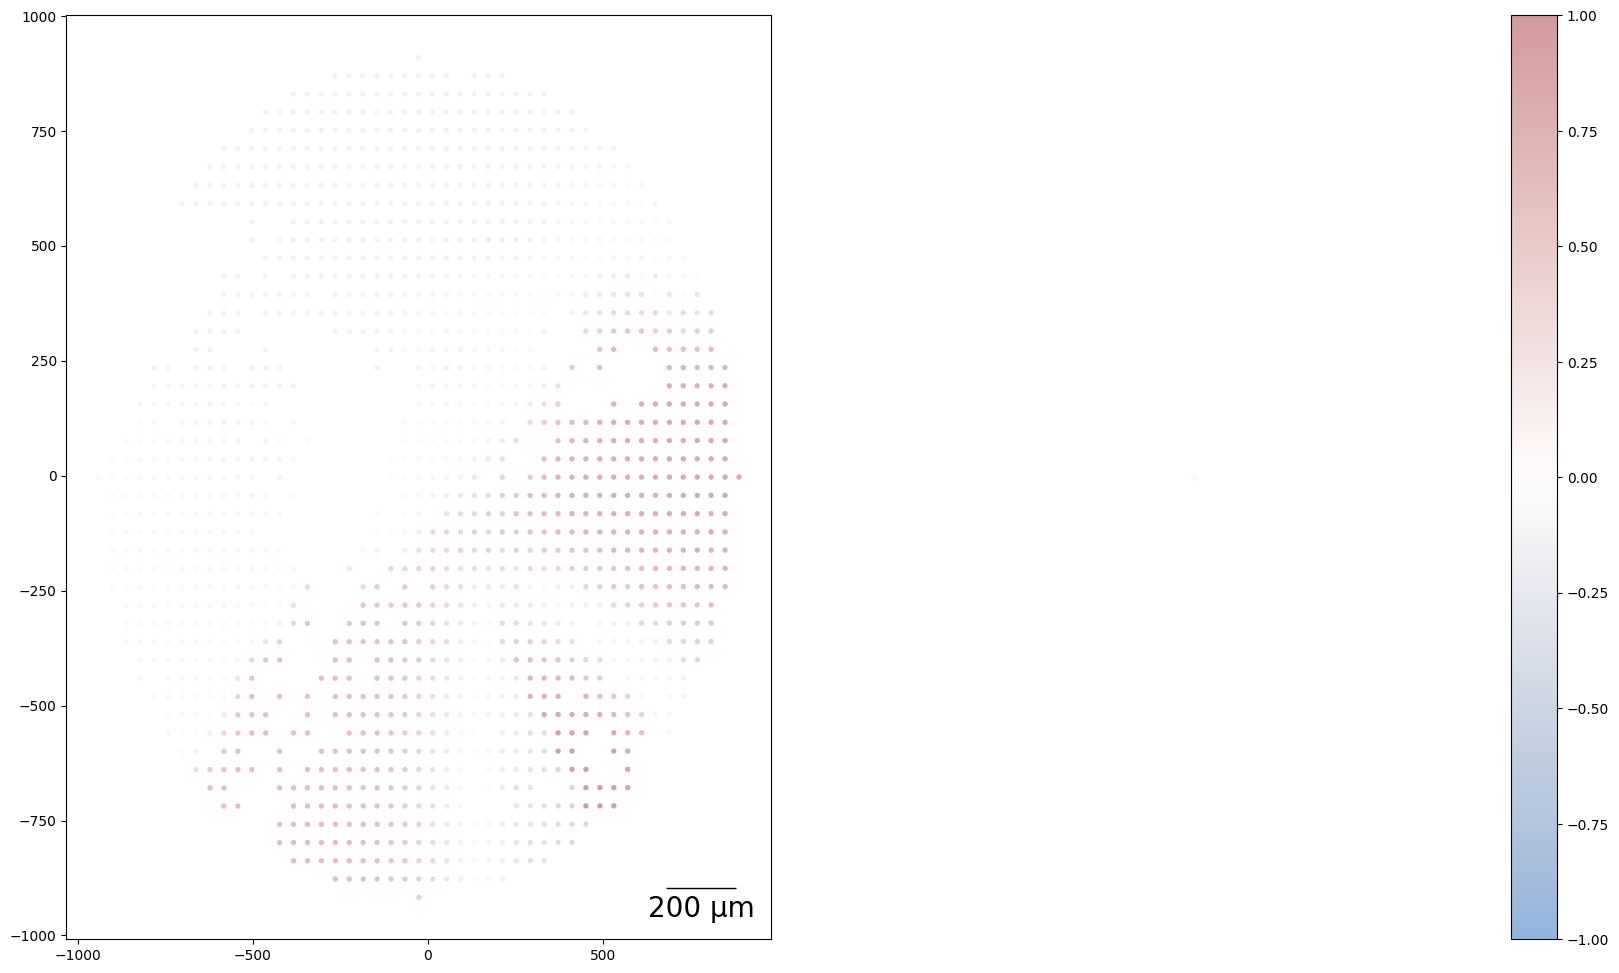

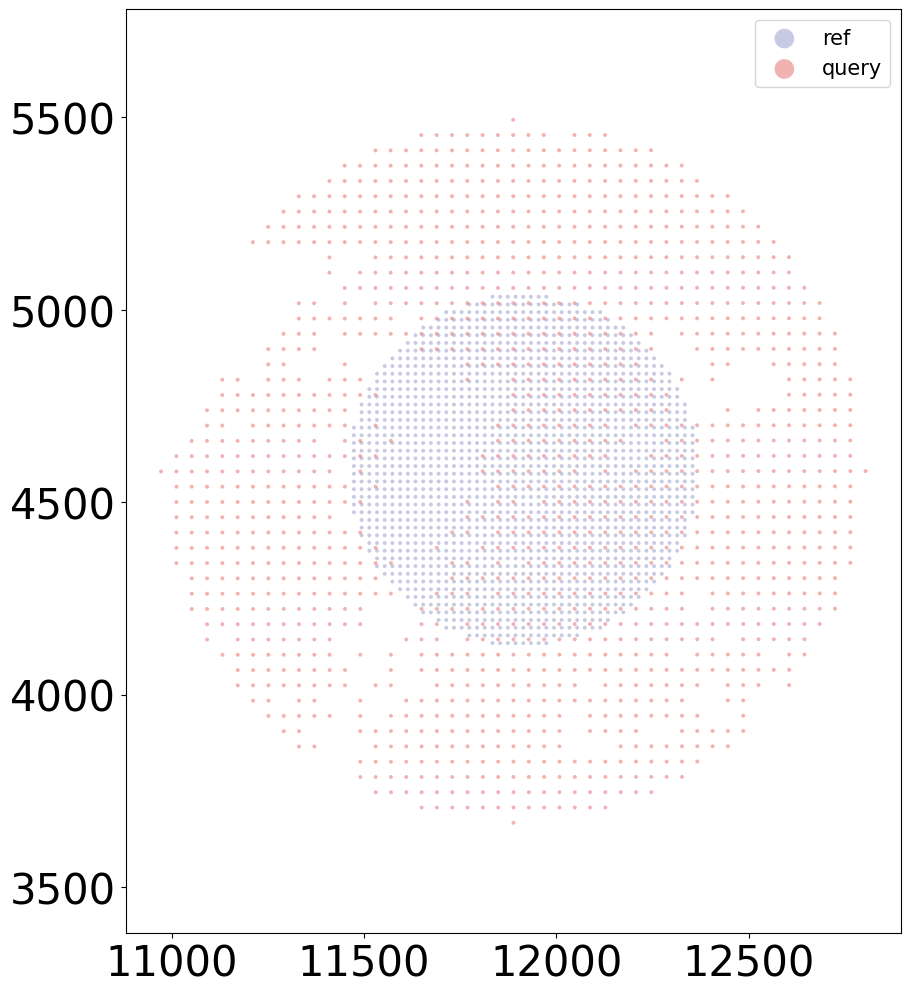

In [33]:
graph_list = ['trans1','meta1']
params_dist = CAST.reg_params(dataname = graph_list[0], 
                            gpu = 0 if torch.cuda.is_available() else -1,
                            diff_step = 5,
                            #### Affine parameters
                            iterations=1,#500
                            dist_penalty1=0.1,#0
                            bleeding=200,#500
                            d_list = [3,2,1,1/2,1/3],
                            attention_params = [None,3,1,0],
                            #### FFD parameters
                            dist_penalty2 = [0],
                            alpha_basis_bs = [500],
                            meshsize = [8],
                            iterations_bs = [0],
                            attention_params_bs = [[None,3,1,0]],
                            mesh_weight = [None])
params_dist.alpha_basis = torch.Tensor([1/1000,1/1000,1/50,5,5]).reshape(5,1).to(params_dist.device)
coords_final = CAST.CAST_STACK(coords_raw, embed_dict, output_path, graph_list,params_dist=params_dist,load_affine_ckpt=False,save_affine_ckpt=True,affine_ckpt_path=None)
# coords_final = CAST.CAST_STACK(coords_raw, embed_dict, output_path, graph_list,params_dist=params_dist,load_affine_ckpt=True,save_affine_ckpt=False,affine_ckpt_path=None,strict_affine_ckpt_match=True)
